# **Feature Engineering & Statistical Significance**

## 1. Import Python Libraries

In [ ]:
import marimo as mo
import pyspark 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

import os
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

## 2. Initialize the spark Session

In [ ]:
spark = SparkSession.builder.appName("Loan_Application_Classifier").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/13 20:02:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 3. Setup the file paths

In [ ]:
# Setup the base path
base_dir = os.path.abspath('/Users/ananddivakaran/Documents/Anand/MDS/loan_app')
output_path_train = os.path.join(base_dir, "data/processed/loan_data_train")
print(f'Train file:{output_path_train}')
output_path_test = os.path.join(base_dir, "data/processed/loan_data_test")
print(f'Test file:{output_path_test}')

Train file:/Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/processed/loan_data_train
Test file:/Users/ananddivakaran/Documents/Anand/MDS/loan_app/data/processed/loan_data_test


## 4. Import Files

In [ ]:
df_train = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(output_path_train)

df_test = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load(output_path_test)

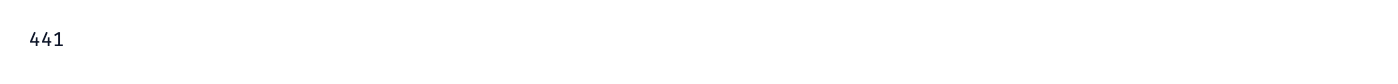

In [ ]:
df_train.count()

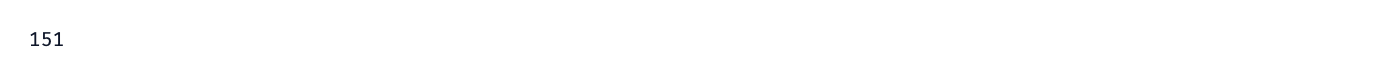

In [ ]:
df_test.count()

In [ ]:
df_train_pd = df_train.toPandas()
df_train_pd.info()

<class 'pandas.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            441 non-null    str    
 1   Gender             433 non-null    str    
 2   Married            441 non-null    str    
 3   Dependents         441 non-null    str    
 4   Education          441 non-null    str    
 5   Self_Employed      441 non-null    str    
 6   ApplicantIncome    441 non-null    str    
 7   CoapplicantIncome  441 non-null    str    
 8   LoanAmount         441 non-null    float64
 9   Loan_Amount_Term   432 non-null    str    
 10  Credit_History     441 non-null    str    
 11  Property_Area      441 non-null    str    
 12  Loan_Status        441 non-null    int32  
dtypes: float64(1), int32(1), str(11)
memory usage: 74.7 KB


## 5. Select categorial variables to check for statistical significance

### 5.1 Identify the categorical variables

In [ ]:
categorical_features = df_train_pd.select_dtypes(include=['category','object','str']).columns.tolist()

### 5.2 Remove featues of no analytical importance

Removing Loan_ID as it is used to identify a row and is of no analytical value.

In [ ]:
index_0 = categorical_features.index("Loan_ID")
print(f'Loan_ID is in index:{index_0}')
categorical_features.pop(index_0)
categorical_features

Loan_ID is in index:0


### 5.3 Remove the target variable

In [ ]:
index_1 = categorical_features.index("Loan_Status")
print(f'Loan_Status is in index:{index_1}')
categorical_features.pop(index_1)
categorical_features

ValueError: 'Loan_Status' is not in list

### 6. Check for statistical significance (Chi-Square Test) of categorical variables

In [ ]:
# Define categorical variables to analyze
#categorical_cols = ['Sex', 'Race', 'Location', 'Body_Part', 'Diagnosis','Product_1','Other_Race','Hispanic','Fire_Involvement','True_Alcohol','True_Drug','Stratum','Treatment_Month']

predator_features = []
# Loop through and plot the "Risk"
for col in categorical_features:
    # Example: Check if Sex predicts Hospitalization
    contingency_table = pd.crosstab(df_train_pd[col], df_train_pd['Loan_Status'])
    #print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    if p < 0.05:
        print(f'{col} is a significant predictor. pvalue {p}')
        predator_features.append(col)
    else:
        print(f'{col} is likely noise.pvalue{p}')

print(f'Predator Features:{predator_features}')

Gender is likely noise.pvalue0.1213107717575253
Married is a significant predictor. pvalue 0.020778340842335246
Dependents is likely noise.pvalue0.6968882493436597
Education is likely noise.pvalue0.24670850509839598
Self_Employed is likely noise.pvalue0.4348289975806473
ApplicantIncome is likely noise.pvalue0.9379352096735949
CoapplicantIncome is likely noise.pvalue0.459554705098157
Loan_Amount_Term is likely noise.pvalue0.5968523847279091
Credit_History is a significant predictor. pvalue 4.904611460122754e-18
Property_Area is a significant predictor. pvalue 0.01305554739671044
Predator Features:['Married', 'Credit_History', 'Property_Area']


### 7. Check for the statistical significance of numeric variables

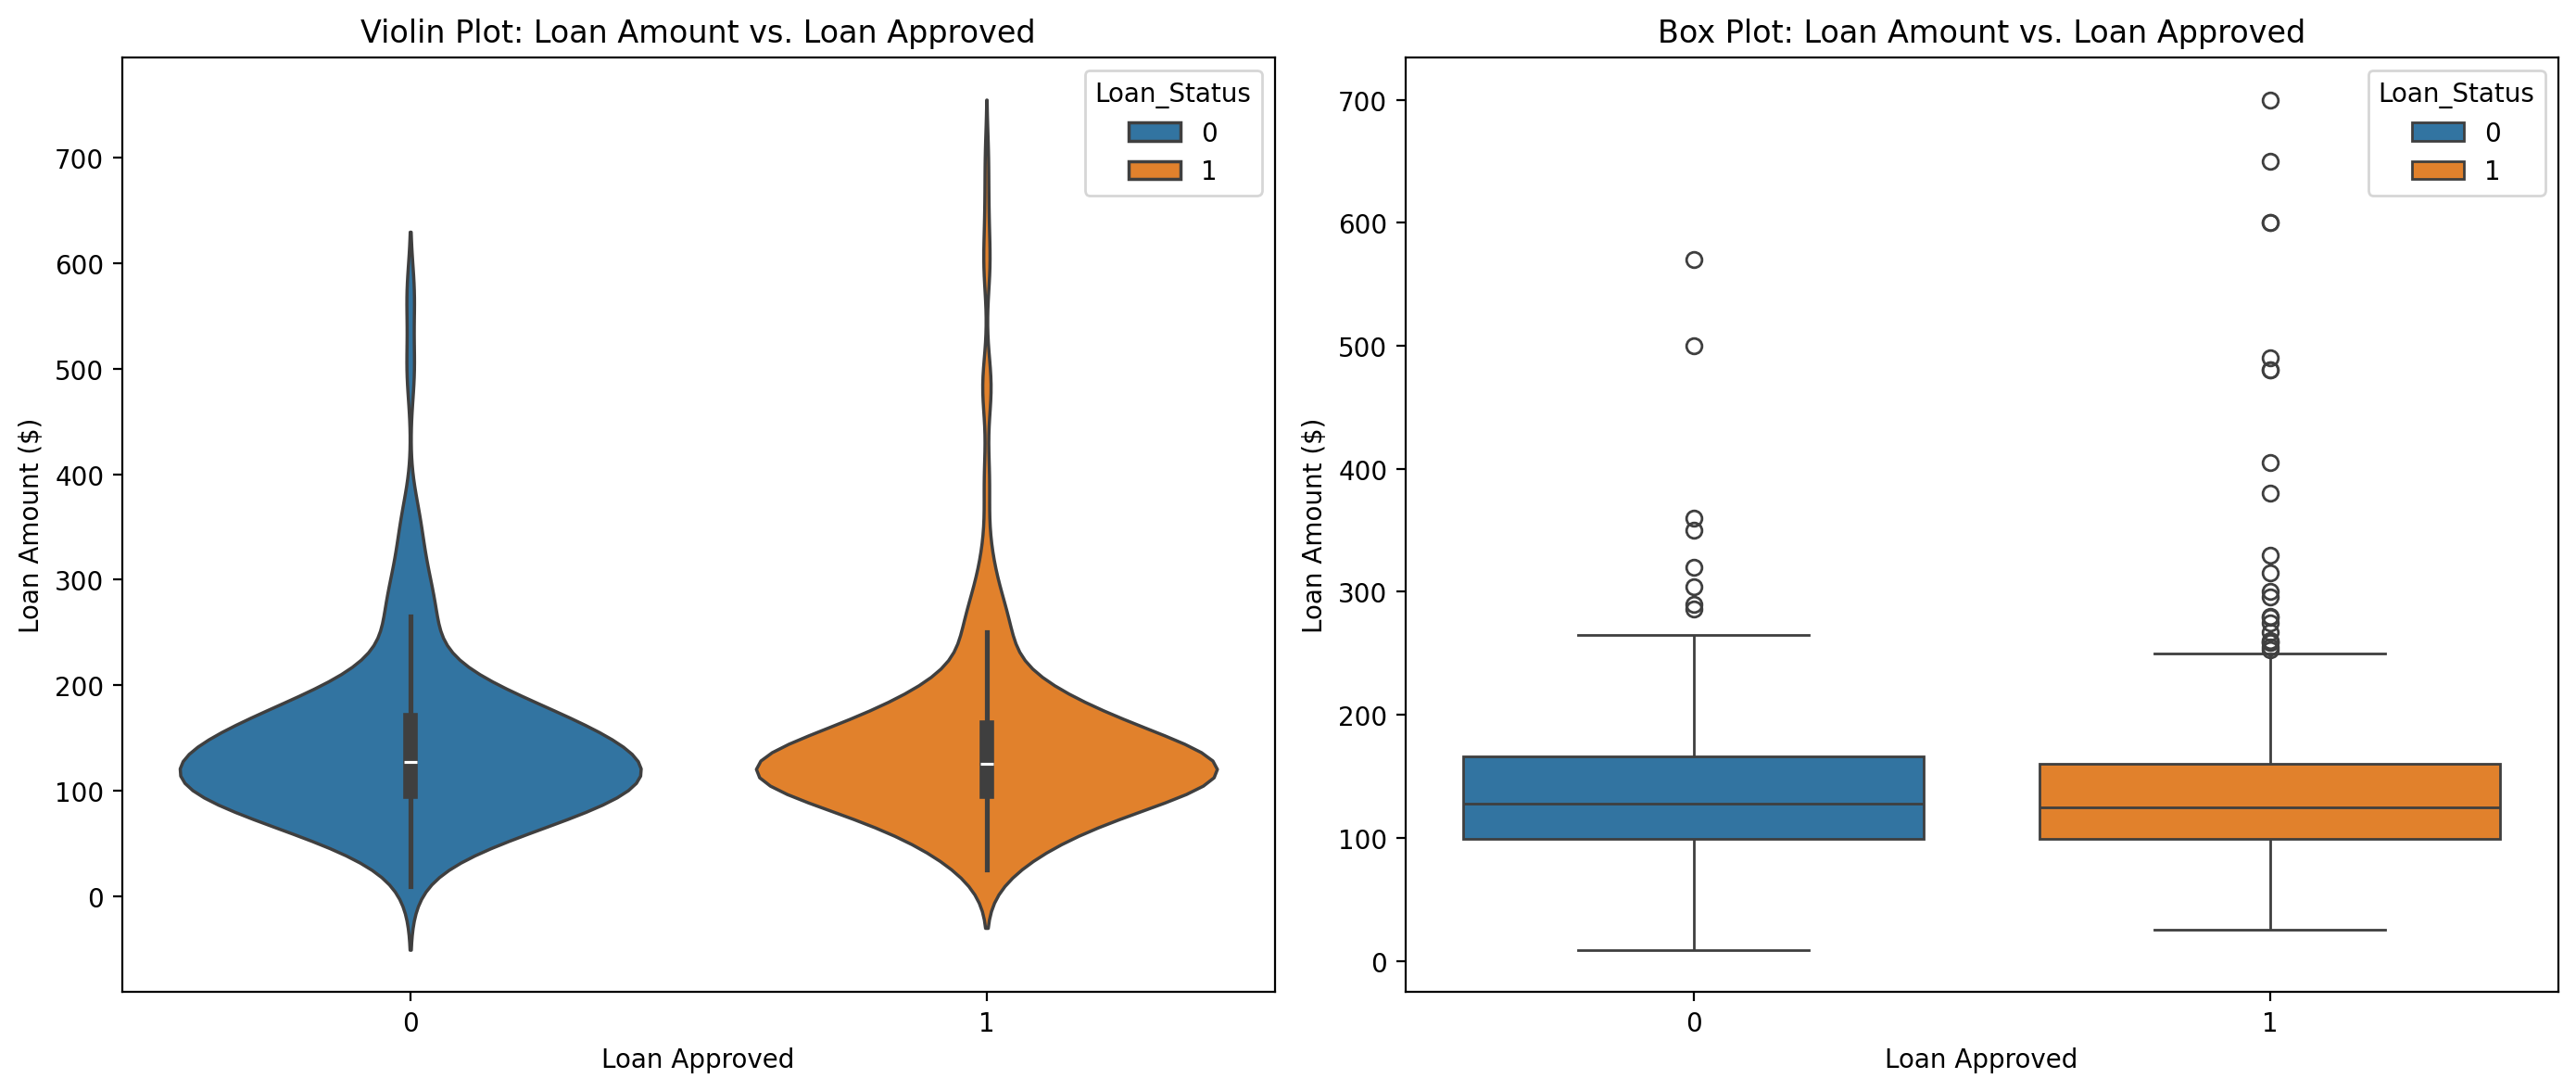

In [ ]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Violin Plot
sns.violinplot(data=df_train_pd, x='Loan_Status', y='LoanAmount', ax=axes[0], hue='Loan_Status')
axes[0].set_title('Violin Plot: Loan Amount vs. Loan Approved')
axes[0].set_ylabel('Loan Amount ($)')
axes[0].set_xlabel('Loan Approved')

# 2. Box Plot 
sns.boxplot(data=df_train_pd, x='Loan_Status', y='LoanAmount', ax=axes[1], hue='Loan_Status')
axes[1].set_title('Box Plot: Loan Amount vs. Loan Approved')
axes[1].set_ylabel('Loan Amount ($)')
axes[1].set_xlabel('Loan Approved')
plt.tight_layout()
plt.show()

The median loan amount for the data approval Yes is similar to the mdeian loan amount for No. There doesnt seem to be any predictive power for the loan amount.